In [1]:
import pandas as pd
import numpy as np
import nltk

In [2]:
!pip install -q kagglehub

In [3]:
import kagglehub

kagglehub.login()

In [4]:
import kagglehub

path = kagglehub.dataset_download(
    "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"
)

print(path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
/kaggle/input/imdb-dataset-of-50k-movie-reviews


In [5]:
import os

os.listdir("/kaggle/input/imdb-dataset-of-50k-movie-reviews")

['IMDB Dataset.csv']

In [6]:
import pandas as pd

df = pd.read_csv("/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
df.shape

(50000, 2)

In [8]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [9]:
df.isnull().sum()

,0
review,0
sentiment,0


In [10]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [11]:
df["review"].iloc[0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [12]:
type(df["review"].iloc[0])

str

In [13]:
len(df["review"].iloc[0])

1761

Data Preprocessing start

In [14]:
# Start Lowercasing
df["clean_review"] = df["review"].str.lower()


In [15]:

import re
# 1. HTML Tags Removal
df["clean_review"] = df["clean_review"].apply(
    lambda text: re.sub(r"<.*?>", " ", text)
)
df["clean_review"].iloc[0]

"one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.  the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.  it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.  i would say the main appeal of the show is due to the fact that it goes where other sh

In [16]:
import string
# 2. Punctuation Removal
df["clean_review"] = df["clean_review"].apply(
    lambda text: text.translate(
        str.maketrans("", "", string.punctuation)
    )
)
df["clean_review"].iloc[0]

'one of the other reviewers has mentioned that after watching just 1 oz episode youll be hooked they are right as this is exactly what happened with me  the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word  it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far away  i would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty 

In [17]:
# 3. Special Character Removal
df["clean_review"] = df["clean_review"].apply(
    lambda text: re.sub(r"[^a-zA-Z\s]", "", text)
)

In [18]:
# 4. Extra Spaces Removal
df["clean_review"] = df["clean_review"].apply(
    lambda text: re.sub(r"\s+", " ", text).strip()
)


In [19]:
print(df["clean_review"].iloc[0])

one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far away i would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty pictur

In [20]:
print("RAW REVIEW:")
print(df["review"].iloc[0])

print("\n" + "="*80 + "\n")

print("CLEAN REVIEW:")
print(df["clean_review"].iloc[0])

RAW REVIEW:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is du

In [21]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [22]:
text="movie was awesome.@"
tokens=text.split()
print(tokens)

['movie', 'was', 'awesome.@']


In [23]:
from nltk.tokenize import word_tokenize
text=df["clean_review"].iloc[0]
tokens=word_tokenize(text)
print(tokens[:30])

['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'oz', 'episode', 'youll', 'be', 'hooked', 'they', 'are', 'right', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'me', 'the', 'first', 'thing']


In [24]:
df["tokens"] = df["clean_review"].apply(word_tokenize)

In [25]:
df[["tokens","clean_review"]].head()

,tokens,clean_review
0,"[one, of, the, other, reviewers, has, mentione...",one of the other reviewers has mentioned that ...
1,"[a, wonderful, little, production, the, filmin...",a wonderful little production the filming tech...
2,"[i, thought, this, was, a, wonderful, way, to,...",i thought this was a wonderful way to spend ti...
3,"[basically, theres, a, family, where, a, littl...",basically theres a family where a little boy j...
4,"[petter, matteis, love, in, the, time, of, mon...",petter matteis love in the time of money is a ...


In [26]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [27]:
#remove stopwords

from nltk.corpus import stopwords
stop_words=set(stopwords.words("english"))

for word in ["not","no","never","nor"]:
  stop_words.discard(word)



In [28]:
df["tokens_no_stopwords"]=df["tokens"].apply(lambda tokens:[word for word in tokens if word not in stop_words])

In [29]:
print("Before:")
print(df["tokens"].iloc[0][:30])

print("\nAfter:")
print(df["tokens_no_stopwords"].iloc[0][:30])

Before:
['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'oz', 'episode', 'youll', 'be', 'hooked', 'they', 'are', 'right', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'me', 'the', 'first', 'thing']

After:
['one', 'reviewers', 'mentioned', 'watching', 'oz', 'episode', 'youll', 'hooked', 'right', 'exactly', 'happened', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scenes', 'violence', 'set', 'right', 'word', 'go', 'trust', 'not', 'show', 'faint', 'hearted', 'timid', 'show']


In [30]:
from nltk.stem import PorterStemmer
stemmer=PorterStemmer()

In [31]:
tokens=df['tokens_no_stopwords'].iloc[0]
stemmed_tokens=[]

for word in tokens:
  stemmed_word = stemmer.stem(word)
  stemmed_tokens.append(stemmed_word)

print(stemmed_tokens[:30])


['one', 'review', 'mention', 'watch', 'oz', 'episod', 'youll', 'hook', 'right', 'exactli', 'happen', 'first', 'thing', 'struck', 'oz', 'brutal', 'unflinch', 'scene', 'violenc', 'set', 'right', 'word', 'go', 'trust', 'not', 'show', 'faint', 'heart', 'timid', 'show']


In [32]:
df['stemmed_tokens']=df['tokens_no_stopwords'].apply(
    lambda tokens:[stemmer.stem(word) for word in tokens]
)

In [33]:
nltk.download('wordnet')


[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [34]:
from nltk.stem import WordNetLemmatizer
lemmatizer=WordNetLemmatizer()

In [35]:
def get_wordnet_pos(tag):
  if tag.startswith("J"):
    return "a"
  elif tag.startswith("V"):
    return "v"
  elif tag.startswith("N"):
    return "n"
  elif tag.startswith("R"):
    return "r"
  else:
    return "n"


In [36]:
import nltk

nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [37]:
def lemmatized_tokens(tokens):
  pos_tag=nltk.pos_tag(tokens)
  lemmatized=[]
  for word,tag in pos_tag:
    pos=get_wordnet_pos(tag)
    lemma=lemmatizer.lemmatize(word,pos)
    lemmatized.append(lemma)
  return lemmatized

In [38]:
tokens = df["tokens_no_stopwords"].iloc[0][:20]

print("Before:")
print(tokens)

print("\nAfter Lemmatization:")
print(lemmatized_tokens(tokens))

Before:
['one', 'reviewers', 'mentioned', 'watching', 'oz', 'episode', 'youll', 'hooked', 'right', 'exactly', 'happened', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scenes', 'violence', 'set']

After Lemmatization:
['one', 'reviewer', 'mention', 'watch', 'oz', 'episode', 'youll', 'hook', 'right', 'exactly', 'happen', 'first', 'thing', 'strike', 'oz', 'brutality', 'unflinching', 'scene', 'violence', 'set']


In [40]:
df['lemmatized_tokens']=df['tokens_no_stopwords'].apply(lemmatized_tokens)

In [41]:
tokens = df["tokens_no_stopwords"].iloc[1][:20]
print(tokens)

print(df["lemmatized_tokens"].iloc[1][:30])

['wonderful', 'little', 'production', 'filming', 'technique', 'unassuming', 'oldtimebbc', 'fashion', 'gives', 'comforting', 'sometimes', 'discomforting', 'sense', 'realism', 'entire', 'piece', 'actors', 'extremely', 'well', 'chosen']
['wonderful', 'little', 'production', 'film', 'technique', 'unassuming', 'oldtimebbc', 'fashion', 'give', 'comfort', 'sometimes', 'discomforting', 'sense', 'realism', 'entire', 'piece', 'actor', 'extremely', 'well', 'choose', 'michael', 'sheen', 'not', 'get', 'polari', 'voice', 'pat', 'truly', 'see', 'seamless']


In [42]:
df['lemmatized_text']=df['lemmatized_tokens'].apply(
    lambda tokens: " ".join(tokens)
)

In [43]:
df['lemmatized_text'].iloc[0][:30]

'one reviewer mention watch oz '

In [ ]:
'''from sklearn.feature_extraction.text import CountVectorizer
bigram_vector=CountVectorizer(ngram_range=(2,2))
X_bigram=bigram_vector.fit_transform(df["lemmatized_text"])
print("Matrix Size : ",X_bigram.shape)
print("Vocab Size :",len(bigram_vector.get_feature_names_out()))
'''

In [51]:
#TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vector=TfidfVectorizer(ngram_range=(1,2),max_features=100000,min_df=2)
X_tfidf=tfidf_vector.fit_transform(df["lemmatized_text"])


In [52]:
print("TF-IDF Matrix Shape:", X_tfidf.shape)

print(tfidf_vector.get_feature_names_out()[:50])

TF-IDF Matrix Shape: (50000, 100000)
['aa' 'aaa' 'aag' 'aaliyah' 'aames' 'aamir' 'aamir khan' 'aardman' 'aaron'
 'aaron carter' 'aaron eckhart' 'aaron sorkin' 'ab' 'ab tak' 'aback'
 'abandon' 'abandon house' 'abandon mine' 'abandoned' 'abandonment' 'abba'
 'abbas' 'abbey' 'abbie' 'abbie hoffman' 'abbot' 'abbot costello' 'abbott'
 'abbott costello' 'abbreviate' 'abby' 'abc' 'abc family' 'abcs' 'abdomen'
 'abduct' 'abduction' 'abductor' 'abe' 'abe lincoln' 'abel' 'aberration'
 'abet' 'abetted' 'abhay' 'abhishek' 'abhorrent' 'abide' 'abigail'
 'ability']


In [53]:
X=X_tfidf


In [54]:
df["label"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

In [55]:
y=df["label"]

In [57]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 100000)
y shape: (50000,)


In [62]:
#Train Test Split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X_tfidf,y,test_size=0.2,random_state=42,stratify=y
)

print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)
print("Y_train shape:",y_train.shape)
print("Y_test shape:",y_test.shape)

X_train shape: (40000, 100000)
X_test shape: (10000, 100000)
Y_train shape: (40000,)
Y_test shape: (10000,)


In [63]:
#Model
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(X_train,y_train)
print("Model training completed.")


Model training completed.


In [64]:
# Prediction

y_pred=model.predict(X_test)
print(y_pred[:20])

[1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 1 1 1 1]


In [65]:
# Accuracy Score

from sklearn.metrics import accuracy_score

accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.8996
Accuracy Percentage: 89.96 %


In [66]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



[[4456  544]
 [ 460 4540]]


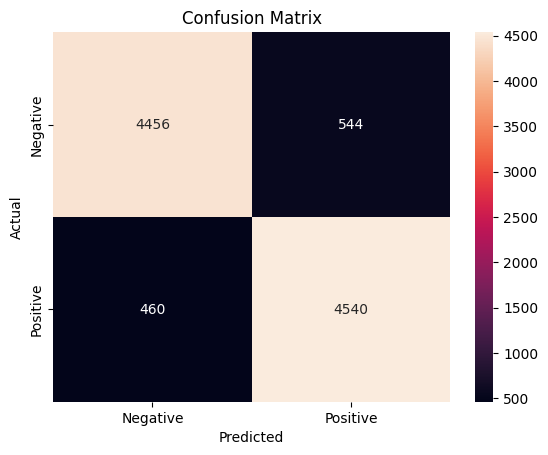

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [70]:
#Navie Bayes

from sklearn.naive_bayes import MultinomialNB

nb_model=MultinomialNB()
nb_model.fit(X_train,y_train)
print("Model Training Completed.")

Model Training Completed.


In [71]:
y_pred_nb=nb_model.predict(X_test)
print(y_pred_nb[:20])


[0 1 1 0 0 0 0 0 1 0 1 1 1 0 1 1 1 1 1 1]


In [73]:
from sklearn.metrics import accuracy_score
accuracy_nb=accuracy_score(y_test,y_pred_nb)
print("Accuracy:",accuracy_nb)
print("Naive Bayes Accuracy Percentage:", accuracy_nb * 100, "%")

Accuracy: 0.8856
Naive Bayes Accuracy Percentage: 88.56 %


In [74]:
# SVM

from sklearn.svm import LinearSVC

svm_model=LinearSVC()
svm_model.fit(X_train,y_train)
print("Model Training Completed.")

Model Training Completed.


In [75]:
y_pred_svm=svm_model.predict(X_test)
print(y_pred_svm[:20])


[1 0 1 0 0 0 0 0 1 0 0 1 1 0 1 1 1 1 1 1]


In [76]:
from sklearn.metrics import accuracy_score
accuracy_svm=accuracy_score(y_test,y_pred_svm)
print("SVM Accuracy:",accuracy_svm)
print("SVM Accuracy Percentage:", accuracy_svm * 100, "%")

SVM Accuracy: 0.9095
SVM Accuracy Percentage: 90.95 %


In [77]:
from sklearn.metrics import classification_report

y_pred_svm = svm_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.91      0.90      0.91      5000
    Positive       0.90      0.92      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



[[4516  484]
 [ 421 4579]]


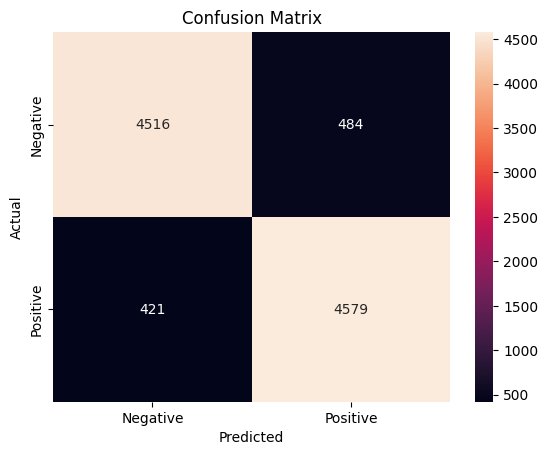

In [78]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [79]:
results = {
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "SVM"
    ],
    "Accuracy": [
        89.96,
        88.00,
        90.95
    ]
}

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy
0  Logistic Regression     89.96
1          Naive Bayes     88.00
2                  SVM     90.95


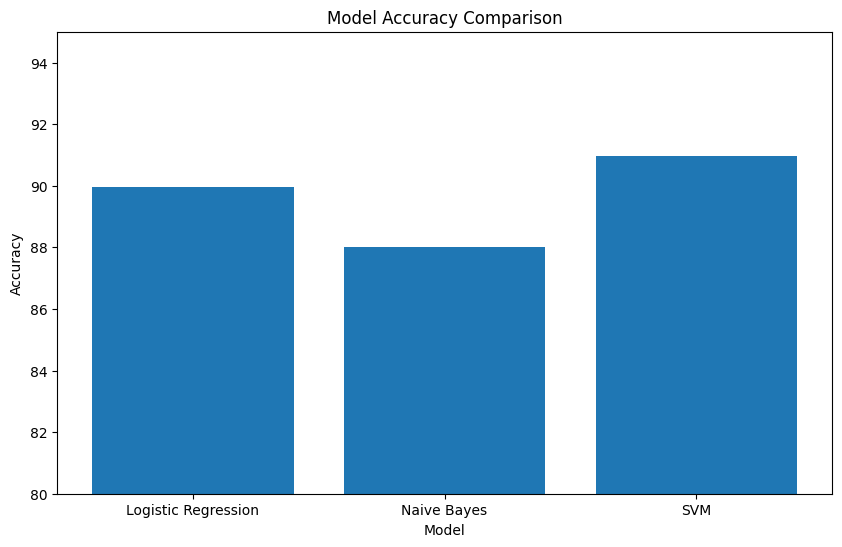

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(80,95)
plt.show()

In [82]:
review=input("enter a review: ")
print(review)

enter a review: The movie is very good !!!
The movie is very good !!!


In [84]:
def predict_sentiment(review):

    # Preprocessing
    text = review.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization
    tokens = word_tokenize(text)

    # Stopword removal
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization
    tokens = lemmatized_tokens(tokens)

    # Convert tokens back to text
    processed_review = " ".join(tokens)

    # TF-IDF transformation
    review_tfidf = tfidf_vector.transform([processed_review])

    # SVM prediction
    prediction = svm_model.predict(review_tfidf)

    if prediction[0] == 1:
        return "Positive 😊"
    else:
        return "Negative 😞"

In [88]:
review = input("Enter a review: ")

result = predict_sentiment(review)

print("Sentiment:", result)

Enter a review: The movie is far from perfect, and at times the pacing feels unnecessarily slow, but it would be unfair to call it a bad film. The performances are surprisingly convincing, the cinematography is beautiful, and a few emotional scenes are genuinely powerful. Although the story becomes predictable toward the end and some characters are not developed as well as they could have been, the overall experience is much more enjoyable than I initially expected. It may not be a masterpiece, but it is definitely worth watching once.
Sentiment: Positive 😊
